In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.impute import SimpleImputer

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_parquet('/content/drive/MyDrive/SB/SB_Project/classification_ring/data/processed/data_ml.parquet')
print(df.shape)
df.head()

Mounted at /content/drive
(1452411, 38)


,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_a5,t_3di_state,t_3di_letter,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
0,1u9c,A,172,,S,H,0.354,-1.001,-0.749,-0.228,...,-0.912,17.0,R,1,0,0,0,0,0,1
1,1u9c,A,184,,G,-,0.250,-2.102,-3.018,-0.384,...,-1.853,19.0,T,1,0,0,0,0,0,0
2,1u9c,A,10,,T,-,0.000,-1.252,2.751,-0.032,...,-3.242,12.0,M,1,0,0,0,0,0,0
3,1u9c,A,133,,V,T,0.021,-1.076,-0.664,-1.337,...,1.313,15.0,P,0,0,0,0,0,0,1
4,1u9c,A,146,,G,T,0.548,1.315,0.127,-0.384,...,2.064,6.0,G,1,0,0,0,0,0,0


In [2]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    's_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    't_3di_state'
]

cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]

feature_cols = num_features + cat_features

print("Label distribution:")
print(df[label_cols].sum().sort_values(ascending=False))

Label distribution:
HBOND        1055929
VDW           737061
PIPISTACK      38283
IONIC          35391
PICATION        8885
SSBOND          2100
PIHBOND         1790
dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

pdb_ids = df['pdb_id'].unique()
print(f"Total unique PDBs: {len(pdb_ids)}")

train_pdbs, temp_pdbs = train_test_split(pdb_ids, test_size=0.30, random_state=42)
val_pdbs, test_pdbs   = train_test_split(temp_pdbs, test_size=0.50, random_state=42)

train_df = df[df['pdb_id'].isin(train_pdbs)].reset_index(drop=True)
val_df   = df[df['pdb_id'].isin(val_pdbs)].reset_index(drop=True)
test_df  = df[df['pdb_id'].isin(test_pdbs)].reset_index(drop=True)

print(f"Train: {len(train_df)} rows, {len(train_pdbs)} PDBs")
print(f"Val:   {len(val_df)} rows, {len(val_pdbs)} PDBs")
print(f"Test:  {len(test_df)} rows, {len(test_pdbs)} PDBs")

Total unique PDBs: 3827
Train: 999083 rows, 2678 PDBs
Val:   238810 rows, 574 PDBs
Test:  214518 rows, 575 PDBs


In [4]:
X_train = train_df[feature_cols].copy()
Y_train = train_df[label_cols].copy()

X_val = val_df[feature_cols].copy()
Y_val = val_df[label_cols].copy()

X_test = test_df[feature_cols].copy()
Y_test = test_df[label_cols].copy()

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (999083, 22)
Y_train shape: (999083, 7)


In [5]:
# One-hot encode categorical features
X_train = pd.get_dummies(X_train, columns=cat_features)
X_val   = pd.get_dummies(X_val,   columns=cat_features)
X_test  = pd.get_dummies(X_test,  columns=cat_features)

# Align columns (in case some categories appear only in train or val)
X_train, X_val  = X_train.align(X_val,  join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Impute remaining NaNs with median
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val   = pd.DataFrame(imputer.transform(X_val),       columns=X_val.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

print("X_train shape after encoding:", X_train.shape)

X_train shape after encoding: (999083, 76)


In [6]:
rf = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
)
rf.fit(X_train, Y_train)


MultiOutputClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                       n_jobs=-1,
                                                       random_state=42))

In [7]:
Y_pred = rf.predict(X_val)

print("=" * 60)
print("PER-CLASS RESULTS ON VALIDATION SET")
print("=" * 60)

for i, label in enumerate(label_cols):
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_val.iloc[:, i],
        Y_pred[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))

macro_f1 = f1_score(Y_val, Y_pred, average='macro', zero_division=0)
micro_f1 = f1_score(Y_val, Y_pred, average='micro', zero_division=0)
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}")

PER-CLASS RESULTS ON VALIDATION SET

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.68      0.34      0.46     65125
     present       0.79      0.94      0.86    173685

    accuracy                           0.78    238810
   macro avg       0.74      0.64      0.66    238810
weighted avg       0.76      0.78      0.75    238810


--- VDW ---
              precision    recall  f1-score   support

      absent       0.60      0.56      0.58    117837
     present       0.60      0.63      0.62    120973

    accuracy                           0.60    238810
   macro avg       0.60      0.60      0.60    238810
weighted avg       0.60      0.60      0.60    238810


--- IONIC ---
              precision    recall  f1-score   support

      absent       0.98      1.00      0.99    233328
     present       0.65      0.31      0.42      5482

    accuracy                           0.98    238810
   macro avg       0.81      0.65      0.70    23

In [8]:

Y_prob = rf.predict_proba(X_val)
Y_prob_present = np.column_stack([prob[:, 1] for prob in Y_prob])
thresholds = np.arange(0.1, 0.9, 0.05)

best_thresholds = {}

for i, label in enumerate(label_cols):
    best_f1 = 0
    best_t = 0.5
    for t in thresholds:
        y_pred_t = (Y_prob_present[:, i] >= t).astype(int)
        f1 = f1_score(Y_val.iloc[:, i], y_pred_t, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds[label] = best_t
    print(f"{label}: best threshold = {best_t:.2f}, F1 = {best_f1:.4f}")

print("\nBest thresholds:", best_thresholds)

HBOND: best threshold = 0.45, F1 = 0.8614
VDW: best threshold = 0.30, F1 = 0.6830
IONIC: best threshold = 0.25, F1 = 0.5623
PIPISTACK: best threshold = 0.35, F1 = 0.8495
PICATION: best threshold = 0.20, F1 = 0.4269
SSBOND: best threshold = 0.45, F1 = 0.9050
PIHBOND: best threshold = 0.10, F1 = 0.0811

Best thresholds: {'HBOND': np.float64(0.45000000000000007), 'VDW': np.float64(0.30000000000000004), 'IONIC': np.float64(0.25000000000000006), 'PIPISTACK': np.float64(0.3500000000000001), 'PICATION': np.float64(0.20000000000000004), 'SSBOND': np.float64(0.45000000000000007), 'PIHBOND': np.float64(0.1)}


In [9]:
print("=" * 60)
print("RESULTS WITH TUNED THRESHOLDS ON VALIDATION SET")
print("=" * 60)

Y_pred_tuned = np.column_stack([
    (Y_prob_present[:, i] >= best_thresholds[label]).astype(int)
    for i, label in enumerate(label_cols)
])

for i, label in enumerate(label_cols):
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_val.iloc[:, i],
        Y_pred_tuned[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))

macro_f1_tuned = f1_score(Y_val, Y_pred_tuned, average='macro', zero_division=0)
micro_f1_tuned = f1_score(Y_val, Y_pred_tuned, average='micro', zero_division=0)
print(f"\nMacro F1 (tuned): {macro_f1_tuned:.4f}")
print(f"Micro F1 (tuned): {micro_f1_tuned:.4f}")

RESULTS WITH TUNED THRESHOLDS ON VALIDATION SET

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.73      0.28      0.40     65125
     present       0.78      0.96      0.86    173685

    accuracy                           0.78    238810
   macro avg       0.75      0.62      0.63    238810
weighted avg       0.77      0.78      0.74    238810


--- VDW ---
              precision    recall  f1-score   support

      absent       0.75      0.13      0.23    117837
     present       0.53      0.96      0.68    120973

    accuracy                           0.55    238810
   macro avg       0.64      0.54      0.45    238810
weighted avg       0.64      0.55      0.46    238810


--- IONIC ---
              precision    recall  f1-score   support

      absent       0.99      0.98      0.99    233328
     present       0.46      0.73      0.56      5482

    accuracy                           0.97    238810
   macro avg       0.72      0.86    

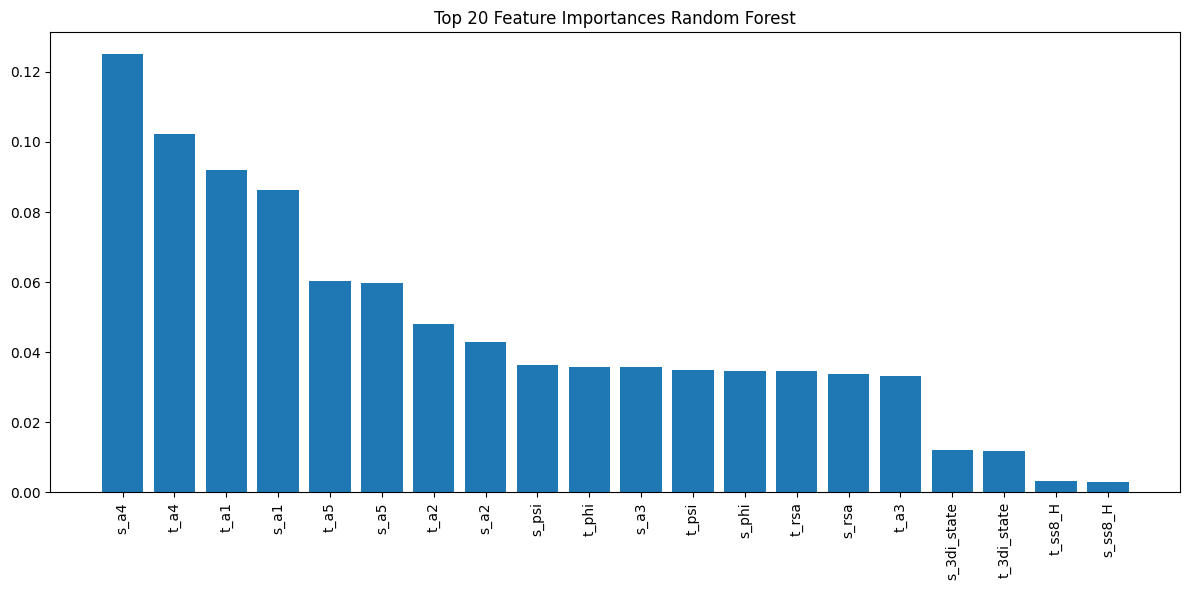

In [10]:

importances = np.mean([
    estimator.feature_importances_
    for estimator in rf.estimators_
], axis=0)

feature_names = X_train.columns.tolist()
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
plt.title("Top 20 Feature Importances Random Forest")
plt.tight_layout()
plt.show()

In [11]:
label_prevalence = Y_val.mean().sort_values(ascending=False)

prevalence_rows = {"baseline": label_prevalence}
false_positive_counts = {}

Y_pred_tuned_df = pd.DataFrame(
    Y_pred_tuned,
    columns=Y_val.columns,
    index=Y_val.index
)

for class_idx, class_name in enumerate(label_cols):
    fp_mask = (Y_val.iloc[:, class_idx] == 0) & (Y_pred_tuned_df.iloc[:, class_idx] == 1)
    false_positives = Y_val.loc[fp_mask]

    n_fp = len(false_positives)
    false_positive_counts[class_name] = n_fp

    if n_fp == 0:
        print(f"\nNo false positives for {class_name}")
        continue
    false_positives_no_self = false_positives.drop(columns=[class_name])


    fp_label_prevalence = false_positives_no_self.mean()
    prevalence_rows[f"FP_{class_name}"] = fp_label_prevalence

fp_prevalence_df = pd.DataFrame(prevalence_rows).T
false_positive_counts = pd.Series(false_positive_counts, name="n_false_positives")

display(fp_prevalence_df)
print(false_positive_counts)


,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
baseline,0.727294,0.022955,0.006277,0.000888,0.024530,0.001809,0.506566
FP_HBOND,NaN,0.009083,0.017206,0.002516,0.019508,0.000490,0.974906
FP_VDW,0.968201,0.024522,0.006779,0.000812,0.029070,0.001692,NaN
FP_IONIC,0.842739,NaN,0.000000,0.000000,0.000000,0.000000,0.504149
FP_PIPISTACK,0.605735,0.000000,0.000000,0.000000,NaN,0.000000,0.567332
FP_PICATION,0.613757,0.000000,NaN,0.001323,0.000000,0.000000,0.618386
FP_SSBOND,0.480000,0.000000,0.000000,0.000000,0.000000,NaN,0.706667
FP_PIHBOND,0.532710,0.000000,0.028037,NaN,0.214953,0.000000,0.546729


HBOND         46903
VDW          102235
IONIC          4820
PIPISTACK      1953
PICATION       1512
SSBOND           75
PIHBOND         214
Name: n_false_positives, dtype: int64


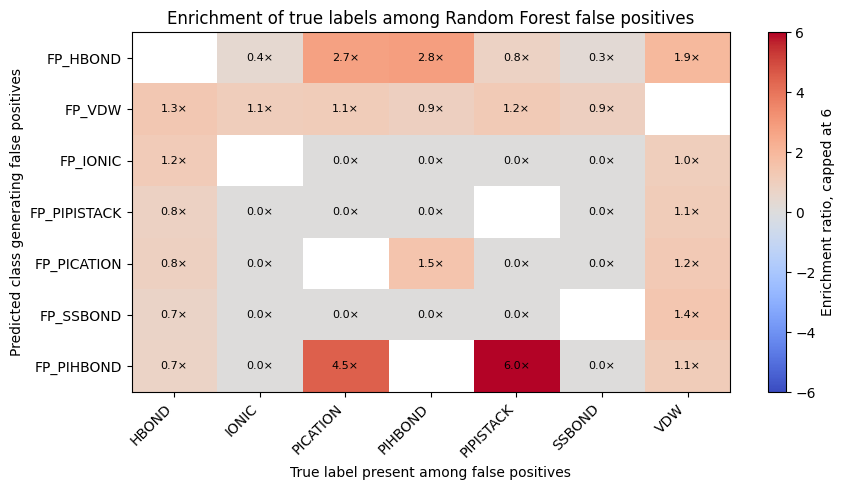

In [12]:
baseline = fp_prevalence_df.loc["baseline"]
fp_rows = fp_prevalence_df.drop(index="baseline")

enrichment_df = fp_rows.divide(baseline, axis=1)

plot_df = enrichment_df.clip(upper=6)

fig, ax = plt.subplots(figsize=(9, 5))

import matplotlib.colors as mcolors

vmax = np.nanmax(np.abs(plot_df.values))
vmin = -vmax
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

im = ax.imshow(plot_df, aspect="auto", cmap="coolwarm", norm=norm)

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_yticks(np.arange(plot_df.shape[0]))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("True label present among false positives")
ax.set_ylabel("Predicted class generating false positives")
ax.set_title("Enrichment of true labels among Random Forest false positives")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Enrichment ratio, capped at 6")

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        value = plot_df.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.1f}×", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


In [13]:
from sklearn.metrics import hamming_loss, accuracy_score

Y_prob_test = rf.predict_proba(X_test)
Y_prob_test_present = np.column_stack([prob[:, 1] for prob in Y_prob_test])
Y_pred_test = np.column_stack([
    (Y_prob_test_present[:, i] >= best_thresholds[label]).astype(int)
    for i, label in enumerate(label_cols)
])

print("=" * 60)
print("PER-CLASS RESULTS ON TEST SET (tuned thresholds)")
print("=" * 60)

for i, label in enumerate(label_cols):
    print(classification_report(
        Y_test.iloc[:, i],
        Y_pred_test[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))

macro_f1_test = f1_score(Y_test, Y_pred_test, average='macro', zero_division=0)
micro_f1_test = f1_score(Y_test, Y_pred_test, average='micro', zero_division=0)
hamming_test  = hamming_loss(Y_test, Y_pred_test)
subset_acc_test = accuracy_score(Y_test, Y_pred_test)

print(f"\nMacro F1:        {macro_f1_test:.4f}")
print(f"Micro F1:        {micro_f1_test:.4f}")
print(f"Hamming loss:    {hamming_test:.4f}")
print(f"Subset accuracy: {subset_acc_test:.4f}")


PER-CLASS RESULTS ON TEST SET (tuned thresholds)

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.74      0.29      0.41     59308
     present       0.78      0.96      0.86    155210

    accuracy                           0.77    214518
   macro avg       0.76      0.62      0.64    214518
weighted avg       0.77      0.77      0.74    214518


--- VDW ---
              precision    recall  f1-score   support

      absent       0.74      0.12      0.21    104998
     present       0.53      0.96      0.69    109520

    accuracy                           0.55    214518
   macro avg       0.64      0.54      0.45    214518
weighted avg       0.64      0.55      0.45    214518


--- IONIC ---
              precision    recall  f1-score   support

      absent       0.99      0.98      0.99    209259
     present       0.48      0.76      0.59      5259

    accuracy                           0.97    214518
   macro avg       0.74      0.87   

In [14]:
test_summary = pd.DataFrame({
    "label": label_cols,
    "support_test": Y_test.sum().values,
    "precision": [
        classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)['1']['precision']
        if '1' in classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)
        else np.nan
        for i in range(len(label_cols))
    ],
    "recall": [
        classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)['1']['recall']
        if '1' in classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)
        else np.nan
        for i in range(len(label_cols))
    ],
    "f1": [
        classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)['1']['f1-score']
        if '1' in classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)
        else np.nan
        for i in range(len(label_cols))
    ],
}).sort_values("support_test", ascending=False)

display(test_summary)


,label,support_test,precision,recall,f1
0,HBOND,155210,0.779149,0.961394,0.860731
1,VDW,109520,0.532929,0.959277,0.685196
3,PIPISTACK,5806,0.765429,0.986910,0.862173
2,IONIC,5259,0.477011,0.757558,0.585409
4,PICATION,1301,0.322820,0.534973,0.402661
5,SSBOND,323,0.825397,0.965944,0.890157
6,PIHBOND,256,0.190909,0.164062,0.176471


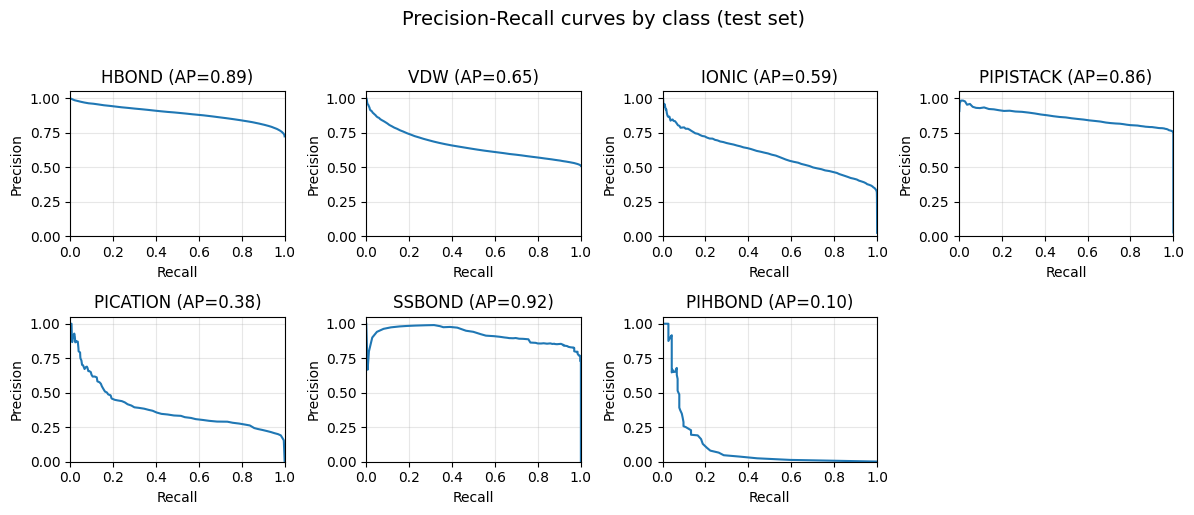

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score

n_classes = len(label_cols)
n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2.5 * n_rows))
axes = axes.flatten()

for i, label in enumerate(label_cols):
    precision, recall, _ = precision_recall_curve(Y_test.iloc[:, i], Y_prob_test_present[:, i])
    ap = average_precision_score(Y_test.iloc[:, i], Y_prob_test_present[:, i])

    ax = axes[i]
    ax.plot(recall, precision)
    ax.set_title(f"{label} (AP={ap:.2f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

for ax in axes[n_classes:]:
    ax.axis("off")

fig.suptitle("Precision-Recall curves by class (test set)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
